## 1.Initialisation et Chargement

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

## 2. Prétraitement des données (Preprocessing)

In [2]:
# 1. Chargement (adapte le nom du fichier)
# Si ton fichier utilise des virgules comme séparateurs
df = pd.read_csv('data/export.csv') 

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# 2. Conversion de la date
# On transforme le texte "2023-11-01..." en objet date compréhensible par Python
df['horodate'] = pd.to_datetime(df['horodate'], utc=True)

# 3. Création des variables temporelles (Feature Engineering)
df['heure'] = df['horodate'].dt.hour
df['jour_nom'] = df['horodate'].dt.day_name()
df['est_weekend'] = df['horodate'].dt.dayofweek >= 5 # Samedi=5, Dimanche=6
df['est_soir'] = df['heure'].between(18, 22)

# On définit l'absence (si conso < 150W par exemple)
SEUIL_ABSENCE = 150
df['est_absent'] = df['valeur'] < SEUIL_ABSENCE

# 4. Aperçu
print(df[['horodate', 'est_weekend', 'est_soir', 'est_absent']].head())
print(f"\nNombre de lignes : {len(df)}")

                   horodate  est_weekend  est_soir  est_absent
0 2023-10-31 23:00:00+00:00        False     False       False
1 2023-10-31 23:30:00+00:00        False     False       False
2 2023-11-01 00:00:00+00:00        False     False       False
3 2023-11-01 00:30:00+00:00        False     False       False
4 2023-11-01 01:00:00+00:00        False     False       False

Nombre de lignes : 8736000


## 3. Visualisation d'un profil type

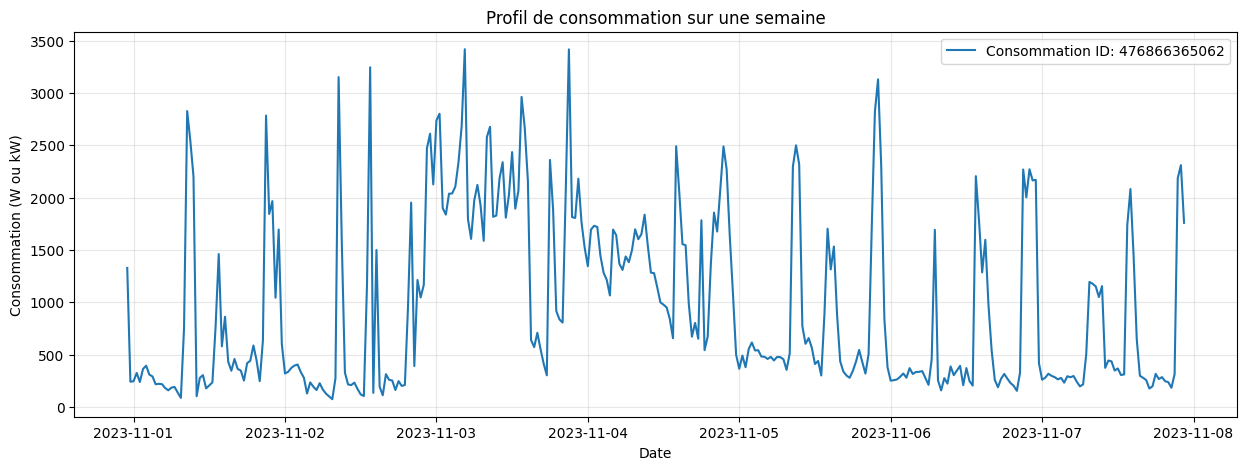

In [3]:
# 1. On choisit un ID de compteur au hasard parmi la liste
un_id = df['id'].unique()[0] 

# 2. On récupère les données de ce client spécifique
client_data = df[df['id'] == un_id].sort_values('horodate')

# 3. On prend juste une petite période (ex: les 7 premiers jours / 336 créneaux de 30min)
semaine = client_data.head(336) 

# 4. On trace le graphique (le fameux "plotlib" de ton tableau !)
plt.figure(figsize=(15, 5))
plt.plot(semaine['horodate'], semaine['valeur'], label=f'Consommation ID: {un_id}')
plt.title(f"Profil de consommation sur une semaine")
plt.xlabel("Date")
plt.ylabel("Consommation (W ou kW)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 4. Agrégation et Création de variables (Feature Engineering)

In [4]:
# 1. Agrégation des statistiques classiques par client
# On calcule la moyenne, le max, le min (talon) et la variance (stabilité)
df_clients = df.groupby('id').agg(
    conso_moyenne=('valeur', 'mean'),
    conso_max=('valeur', 'max'),
    talon_min=('valeur', 'min'),
    variance_conso=('valeur', 'std'),
    taux_absence=('est_absent', 'mean')
).reset_index()

# 2. Calcul du ratio Weekend / Semaine 
# (On isole les moyennes WE et Semaine pour chaque ID)
conso_we = df[df['est_weekend'] == True].groupby('id')['valeur'].mean()
conso_semaine = df[df['est_weekend'] == False].groupby('id')['valeur'].mean()

# On "mappe" ces résultats sur notre tableau df_clients en utilisant l'ID
df_clients['ratio_weekend_semaine'] = df_clients['id'].map(conso_we / conso_semaine)

# 3. Calcul du poids de la consommation du soir (18h-22h)
conso_soir = df[df['est_soir'] == True].groupby('id')['valeur'].mean()
df_clients['poids_soir'] = df_clients['id'].map(conso_soir / df_clients['conso_moyenne'])

# 4. Nettoyage des valeurs manquantes ou infinies (au cas où)
df_clients = df_clients.replace([np.inf, -np.inf], np.nan)
df_clients = df_clients.fillna(0)

print(f"Dataset réduit créé : {len(df_clients)} clients et {len(df_clients.columns)} variables.")
print(df_clients.head())

Dataset réduit créé : 500 clients et 8 variables.
            id  conso_moyenne  conso_max  talon_min  variance_conso  taux_absence  ratio_weekend_semaine  poids_soir
0   1704875583     844.783677     4566.3        0.0      798.035907      0.168670               1.041140         0.0
1   6674572658     803.093739     5544.9        0.0      899.581537      0.321543               1.048049         0.0
2   9993623468     631.666804     6726.1        0.0      843.747070      0.307005               1.120977         0.0
3  10607320546     716.334495     4846.6        0.0      678.233493      0.102507               1.054801         0.0
4  11239534806     553.425418     5646.2        1.9      772.747321      0.295330               1.144875         0.0


In [5]:
# On regarde les statistiques globales (moyenne, min, max) pour chaque nouvelle variable
stats = df_clients[['conso_moyenne', 'taux_absence', 'ratio_weekend_semaine', 'poids_soir']].describe()
print(stats)

       conso_moyenne  taux_absence  ratio_weekend_semaine  poids_soir
count     500.000000    500.000000             500.000000       500.0
mean      663.643925      0.270023               1.072343         0.0
std       129.161680      0.114883               0.049023         0.0
min       221.466289      0.049794               0.971719         0.0
25%       586.525927      0.188502               1.038888         0.0
50%       662.443372      0.257097               1.066503         0.0
75%       747.340051      0.340302               1.094083         0.0
max      1014.952003      0.743704               1.294683         0.0


## 6. Préparation pour le Clustering (Scaling)

In [6]:
# 1. On définit les colonnes qu'on donne à l'IA pour réfléchir
# On prend tout sauf l'ID (car l'ID n'est pas une habitude de consommation)
colonnes_ia = ['conso_moyenne', 'conso_max', 'talon_min', 'variance_conso', 
               'taux_absence', 'ratio_weekend_semaine', 'poids_soir']

X = df_clients[colonnes_ia]

# 2. On applique la normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Données normalisées. On est prêts pour le clustering !")

Données normalisées. On est prêts pour le clustering !


## 7. Application du K-Means

In [7]:
# On initialise le K-Means pour 2 groupes
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

# On calcule les clusters
df_clients['cluster'] = kmeans.fit_predict(X_scaled)

# On affiche le nombre de clients par groupe
print("Répartition des clients par cluster :")
print(df_clients['cluster'].value_counts())

Répartition des clients par cluster :
cluster
0    285
1    215
Name: count, dtype: int64


## 8. Évaluation et Interprétation

In [8]:
# 1. Calcul du Silhouette Score
score = silhouette_score(X_scaled, df_clients['cluster'])
print(f"Silhouette Score : {score:.3f}")

# 2. On compare les moyennes de chaque groupe pour deviner qui est qui
comparaison = df_clients.groupby('cluster')[['conso_moyenne', 'taux_absence', 'ratio_weekend_semaine', 'conso_max']].mean()
print("\nComparaison des moyennes par groupe :")
print(comparaison)

Silhouette Score : 0.205

Comparaison des moyennes par groupe :
         conso_moyenne  taux_absence  ratio_weekend_semaine    conso_max
cluster                                                                 
0           733.182436      0.210182               1.060094  5480.121754
1           571.464968      0.349348               1.088580  6823.759535


## 9. Visualisation des résultats (Boxplots)

C:\Users\roman\AppData\Local\Temp\ipykernel_15976\2066788408.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='conso_moyenne', data=df_clients, ax=ax1, palette="Set2")
C:\Users\roman\AppData\Local\Temp\ipykernel_15976\2066788408.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='taux_absence', data=df_clients, ax=ax2, palette="Set2")


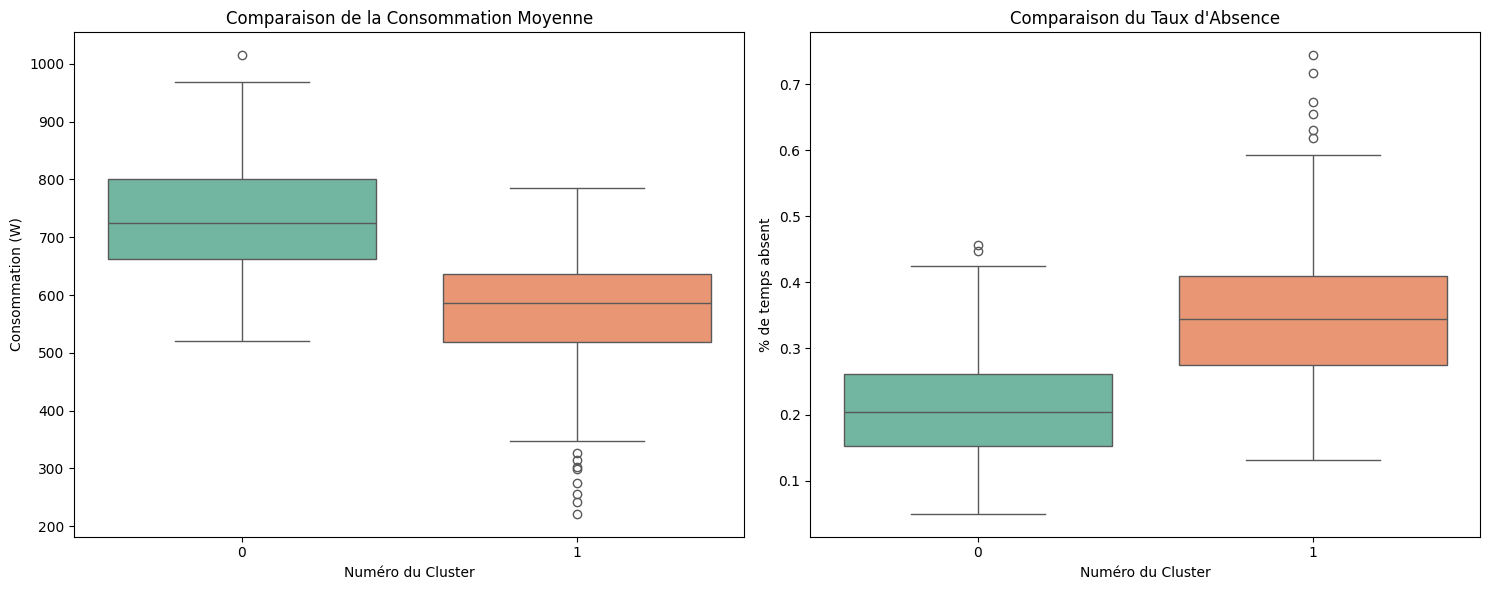

In [9]:
# On crée une figure avec deux graphiques côte à côte
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot 1 : La consommation moyenne
sns.boxplot(x='cluster', y='conso_moyenne', data=df_clients, ax=ax1, palette="Set2")
ax1.set_title('Comparaison de la Consommation Moyenne')
ax1.set_xlabel('Numéro du Cluster')
ax1.set_ylabel('Consommation (W)')

# Boxplot 2 : Le taux d'absence
sns.boxplot(x='cluster', y='taux_absence', data=df_clients, ax=ax2, palette="Set2")
ax2.set_title("Comparaison du Taux d'Absence")
ax2.set_xlabel('Numéro du Cluster')
ax2.set_ylabel('% de temps absent')

plt.tight_layout()
plt.show()

## 10. Profil de consommation sur 24h

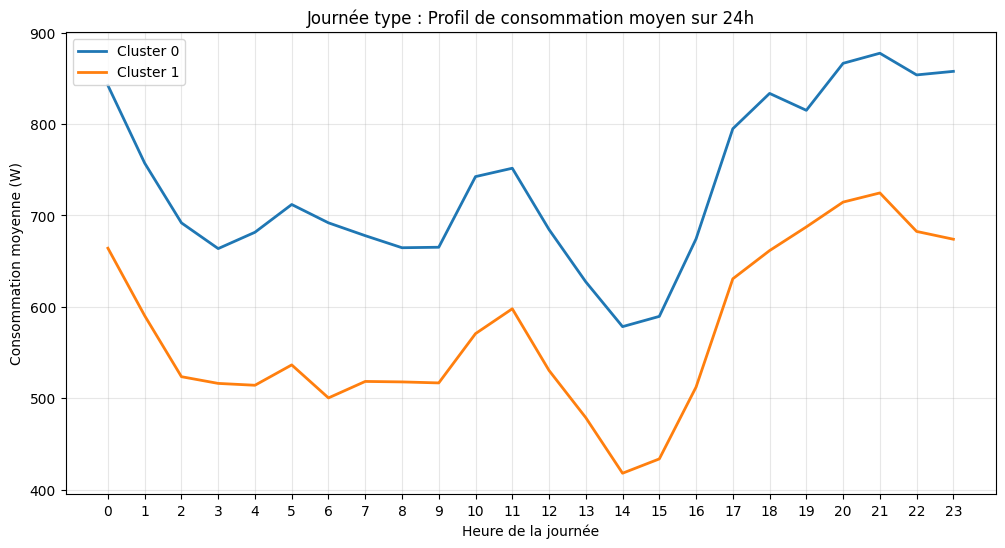

In [10]:
# On recolle le numéro de cluster de chaque client sur le dataset complet
df_final = df.merge(df_clients[['id', 'cluster']], on='id')

# On calcule la moyenne par heure pour chaque groupe
profil_horaire = df_final.groupby(['cluster', 'heure'])['valeur'].mean().unstack(0)

# On dessine la courbe
profil_horaire.plot(figsize=(12, 6), linewidth=2)
plt.title("Journée type : Profil de consommation moyen sur 24h")
plt.xlabel("Heure de la journée")
plt.ylabel("Consommation moyenne (W)")
plt.xticks(range(0, 24)) # Pour afficher toutes les heures de 0 à 23
plt.legend(["Cluster 0", "Cluster 1"])
plt.grid(True, alpha=0.3)
plt.show()

## 11. KPI Metrics et Conclusion

In [11]:
# 1. On sépare nos deux groupes avec leurs nouveaux noms
principales = df_clients[df_clients['cluster'] == 0]
secondaires = df_clients[df_clients['cluster'] == 1]

# 2. On calcule les chiffres clés
nb_total = len(df_clients)
pct_secondaires = (len(secondaires) / nb_total) * 100

baisse_conso = 100 - (secondaires['conso_moyenne'].mean() / principales['conso_moyenne'].mean() * 100)

# 3. Affichage du rapport final
print("📊 --- RAPPORT FINAL ENEDIS --- 📊\n")
print(f"Sur un total de {nb_total} résidences analysées :")
print(f"- {len(principales)} ont été classées comme Résidences Principales.")
print(f"- {len(secondaires)} ont été classées comme Résidences Secondaires ({pct_secondaires:.1f}% du parc).\n")

print("💡 --- DIFFÉRENCES CLÉS --- 💡")
print(f"- Économie d'énergie : Les résidences secondaires consomment en moyenne {baisse_conso:.1f}% de moins que les principales.")
print(f"- Temps d'absence : Le taux d'absence moyen est de {secondaires['taux_absence'].mean()*100:.1f}% pour les secondaires, contre {principales['taux_absence'].mean()*100:.1f}% pour les principales.")

📊 --- RAPPORT FINAL ENEDIS --- 📊

Sur un total de 500 résidences analysées :
- 285 ont été classées comme Résidences Principales.
- 215 ont été classées comme Résidences Secondaires (43.0% du parc).

💡 --- DIFFÉRENCES CLÉS --- 💡
- Économie d'énergie : Les résidences secondaires consomment en moyenne 22.1% de moins que les principales.
- Temps d'absence : Le taux d'absence moyen est de 34.9% pour les secondaires, contre 21.0% pour les principales.


## 12. Export du livrable final

In [12]:
# 1. On crée une nouvelle colonne plus lisible que "0" ou "1"
df_clients['type_residence'] = df_clients['cluster'].map({0: 'Principale', 1: 'Secondaire'})

# 2. On sélectionne uniquement l'ID du client et son type de résidence
livrable_final = df_clients[['id', 'type_residence']]

# 3. On exporte ce tableau propre dans un nouveau fichier CSV
livrable_final.to_csv('resultats_classification_enedis.csv', index=False)

print("Le fichier final a été créé avec succès !")
print("\nAperçu des 5 premiers clients :")
print(livrable_final.head())

Le fichier final a été créé avec succès !

Aperçu des 5 premiers clients :
            id type_residence
0   1704875583     Principale
1   6674572658     Principale
2   9993623468     Secondaire
3  10607320546     Principale
4  11239534806     Secondaire
